<a href="https://colab.research.google.com/github/gustavo00000000/mis-primeros-pasos-data-science/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# importacion de la base



In [ ]:
import kagglehub
path = kagglehub.dataset_download("brendan45774/test-file")

100%|██████████| 11.2k/11.2k [00:00<00:00, 8.29MB/s]

Extracting files...


visualizacion

In [ ]:
import pandas as pd
import os

# Esto nos ayuda a ver exactamente qué archivo se descargó
archivos = os.listdir(path)
print(f"Archivos descargados: {archivos}")

# Leemos el archivo (asumiendo que es un CSV)
# Si el nombre es diferente al del print de arriba, cámbialo aquí
df = pd.read_csv(f"{path}/{archivos[0]}")

# ¡Veamos qué hay dentro!
df.head()

Archivos descargados: ['tested.csv']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Aplicar las habilidades de la Semana 1

Una vez que veas la tabla con df.head(), ejecuta estas tres celdas por separado para completar tu entrenamiento de "detective de datos":

    Celda A: df.info()
    (Mira si hay columnas con valores "Non-Null" menores al total de filas. Esas son las que tienen huecos).

    Celda B: df.describe()
    (Observa los promedios y valores máximos. ¿Hay algo que te parezca extraño en el comportamiento de los números?)

    Celda C (Análisis de Nulos): df.isnull().sum()
    (Esto te dirá exactamente cuántos datos faltan en cada columna).

`df.info()` *sirve* pera ver si no hay valores vacios

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


`df.describe()`  decribe el comportamiento basico de los datos, conteo, media, desviacion, percentiles minimo y maximos

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


`df.isnull()` te clasifica los vacios `.sum()` suma los vacios para saber cuantos te faltan en comparacion a los demas


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


2. ¿Cómo graficar la distribución?

¡Claro que sí! Los números de df.describe() se entienden mucho mejor visualmente. Para ver la distribución (por ejemplo, si había más niños que ancianos), usamos un Histograma.
La línea curva (kde=True) te ayuda a ver la "forma" de la distribución.

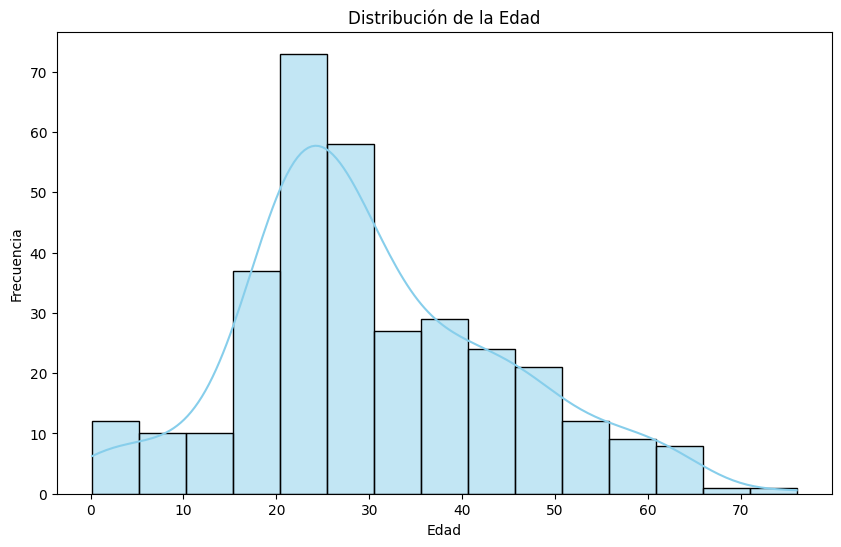

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue')
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

3. ¿Cómo saber si hay correlación entre todo?

Para comparar todas las filas numéricas y ver cómo se relacionan entre sí (por ejemplo, ¿si pagaron más por el ticket eran más jóvenes?), usamos una Matriz de Correlación.

Ejecuta este código para ver un "mapa de calor" de las relaciones:

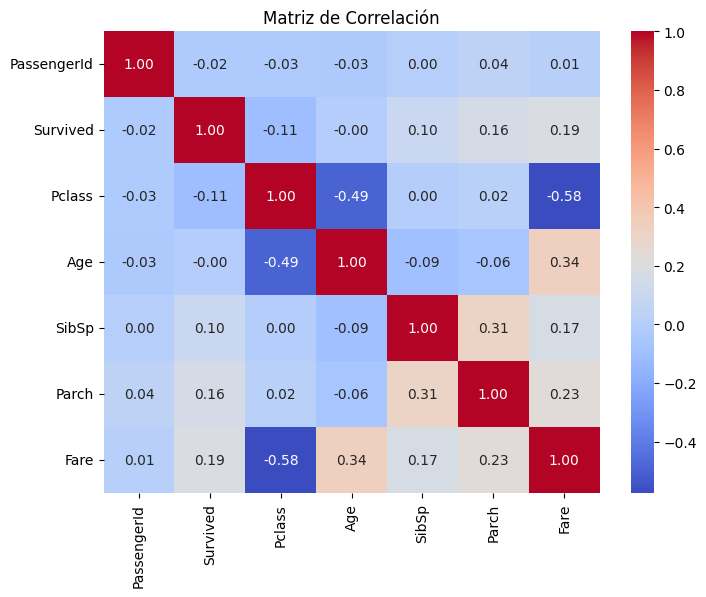

In [ ]:
# Seleccionamos solo columnas numéricas para la correlación
columnas_numericas = df.select_dtypes(include=['number'])
matriz_corr = columnas_numericas.corr()

# Graficamos
plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
# Creamos una columna que sea Verdadera si la edad es nula
df['Falta_Edad'] = df['Age'].isnull()

# Comparamos el precio del ticket (Fare) entre los que tienen edad y los que no
print(df.groupby('Falta_Edad')['Fare'].mean())

Falta_Edad
False    40.982087
True     15.017055
Name: Fare, dtype: float64
